<a href="https://colab.research.google.com/github/nickcanoy/Masters_in_DataScience/blob/main/Assignment_2_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RODENICK CANOY | Assignment 2-Polynomial Regression | PSMDSSC 103-Applied Machine Learning

In [ ]:
# Step 0: Install missing dependencies (if needed)
!pip install seaborn scikit-learn

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

In [ ]:
# Step 2: Load dataset from uploaded content
# Replace path if needed
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

# Basic cleaning
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour

print(df.head())
print(df.info())

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description           date_time  traffic_volume  hour  
0    scattered clouds 2012-10-02 09:00:00            5545     9  
1       broken clouds 2012-10-02 10:00:00            4516    10  
2     overcast clouds 2012-10-02 11:00:00            4767    11  
3     overcast clouds 2012-10-02 12:00:00            5026    12  
4       broken clouds 2012-10-02 13:00:00            4918    13  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----      

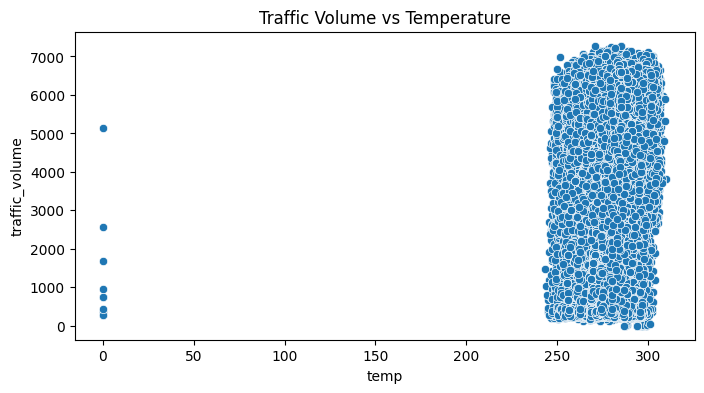

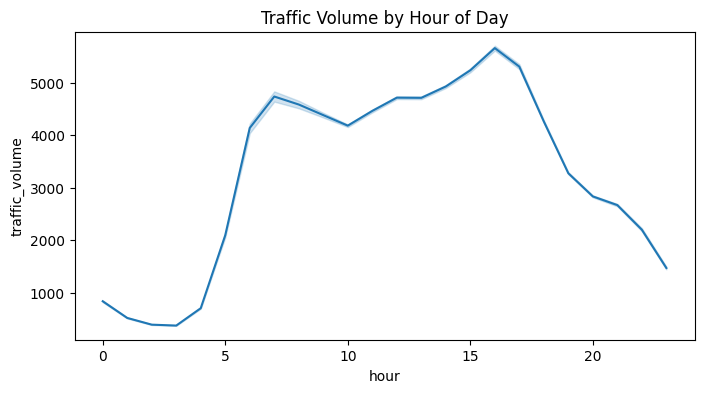

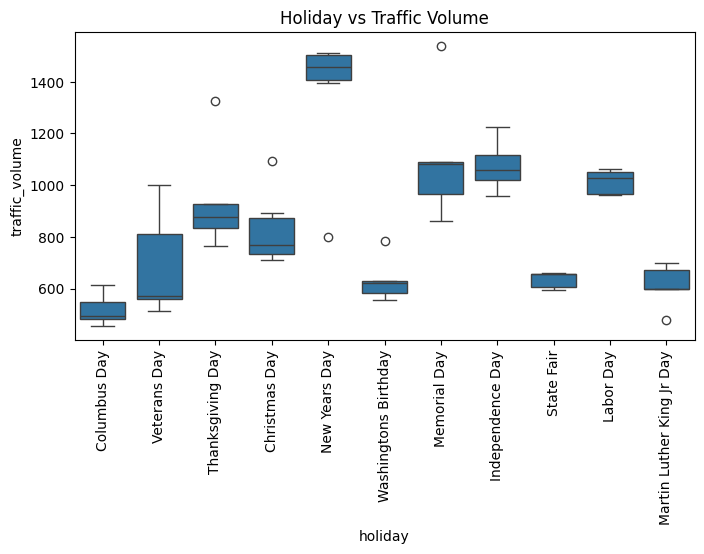

In [ ]:
# ============================================================
# STEP 2: EXPLORATORY DATA ANALYSIS
# ============================================================

plt.figure(figsize=(8,4))
sns.scatterplot(x='temp', y='traffic_volume', data=df)
plt.title("Traffic Volume vs Temperature")
plt.show()

plt.figure(figsize=(8,4))
sns.lineplot(x='hour', y='traffic_volume', data=df)
plt.title("Traffic Volume by Hour of Day")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='holiday', y='traffic_volume', data=df)
plt.xticks(rotation=90)
plt.title("Holiday vs Traffic Volume")
plt.show()

In [ ]:
# ============================================================
# STEP 3: FEATURE ENGINEERING
# ============================================================

# Select simple features for polynomial regression
X = df[['temp', 'hour']]
y = df['traffic_volume']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ============================================================
# STEP 4: POLYNOMIAL REGRESSION – DEGREES 1 TO 4
# ============================================================

results = []

for degree in range(1, 5):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('scaler', StandardScaler()),
        ('linreg', LinearRegression())
    ])

    # Cross-validation (5-fold)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

    # Fit model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)

    results.append([degree, rmse, r2, mae, np.mean(cv_scores)*-1])

    print(f"Degree {degree} Results:")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  R²   = {r2:.4f}")
    print(f"  MAE  = {mae:.2f}")
    print("------------------------------------")

Degree 1 Results:
  RMSE = 1846.58
  R²   = 0.1375
  MAE  = 1640.68
------------------------------------
Degree 2 Results:
  RMSE = 1167.92
  R²   = 0.6550
  MAE  = 904.19
------------------------------------
Degree 3 Results:
  RMSE = 1136.07
  R²   = 0.6735
  MAE  = 865.40
------------------------------------
Degree 4 Results:
  RMSE = 1106.90
  R²   = 0.6901
  MAE  = 825.72
------------------------------------


   Degree         RMSE        R2          MAE        CV_MSE
0       1  1846.576589  0.137515  1640.677888  3.428461e+06
1       2  1167.921771  0.654980   904.194921  1.397078e+06
2       3  1136.070169  0.673542   865.403959  1.334546e+06
3       4  1106.901244  0.690091   825.716432  1.268003e+06


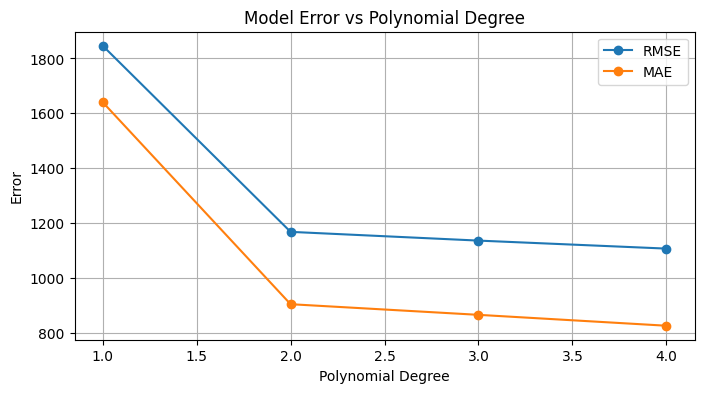

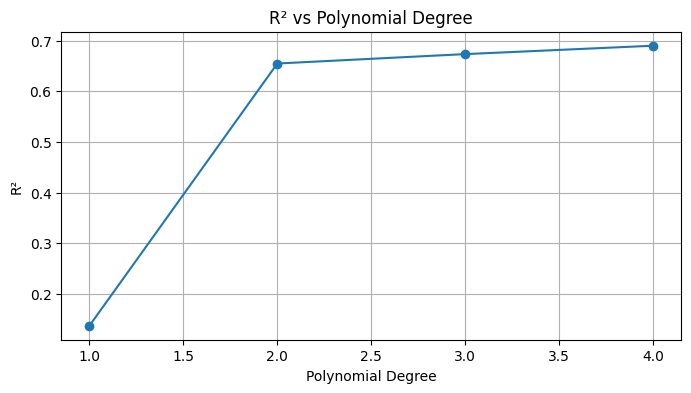

In [ ]:
# ============================================================
# STEP 5: RESULTS SUMMARY
# ============================================================

results_df = pd.DataFrame(results, columns=['Degree', 'RMSE', 'R2', 'MAE', 'CV_MSE'])
print(results_df)

plt.figure(figsize=(8,4))
plt.plot(results_df['Degree'], results_df['RMSE'], marker='o', label='RMSE')
plt.plot(results_df['Degree'], results_df['MAE'], marker='o', label='MAE')
plt.title("Model Error vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(results_df['Degree'], results_df['R2'], marker='o', label='R² Score')
plt.title("R² vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("R²")
plt.grid()
plt.show()


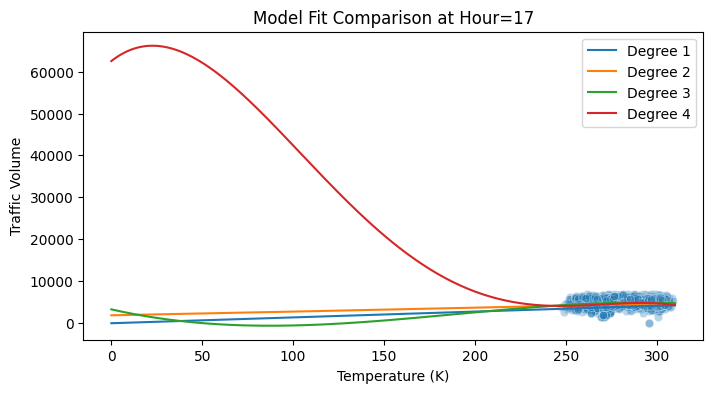

In [ ]:
# ============================================================
# Visualizing model fit for temperature vs traffic
# ============================================================

temp_range = np.linspace(df['temp'].min(), df['temp'].max(), 300)
hour_fixed = 17  # fix to 5PM rush hour
X_plot = pd.DataFrame({'temp': temp_range, 'hour': hour_fixed})

plt.figure(figsize=(8,4))
sns.scatterplot(x='temp', y='traffic_volume', data=df[df['hour']==hour_fixed], alpha=0.3)

for degree in range(1,5):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('scaler', StandardScaler()),
        ('linreg', LinearRegression())
    ])
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)
    plt.plot(temp_range, y_plot, label=f"Degree {degree}")

plt.title(f"Model Fit Comparison at Hour={hour_fixed}")
plt.xlabel("Temperature (K)")
plt.ylabel("Traffic Volume")
plt.legend()
plt.show()
